# LLM-based TTS

# Agenda
1. [TortoiseTTS](#TortoiseTTS)
1. [Overview](#overview-of-tts-systems)
1. [Creating LLM TTS](#own-small-tts)
1. [Homework](#Homework)

# Intro

# TortoiseTTS

DALL-E inspired TTS

paper: [Better speech synthesis through scaling](https://arxiv.org/pdf/2305.07243)

## Ideas


1. LLM for core generation (GPT2)
1. Diffusion for details rendering
1. Large pretraining


Questions to answer:
1. How to represent audio to make use of LLM?
1. How to condition generations on text?
1. How to condition on speaker?
1. How to reconstruct audio from generated tokens?


## General inference scheme


![image.png](attachment:image.png)


## 1. VQ-VAE


paper: [Neural Discrete Representation Learning](https://arxiv.org/pdf/1711.00937)

![image.png](attachment:image.png)

![image.png](attachment:image.png)


## Autoregressive Transformer


BPE

check whisper lection

* causal attention
* transformer blocks
* shift loss

![image.png](attachment:image.png)

## Speaker conditioning

![image.png](attachment:image.png)

## Diffusion decoder

* DDIM
* latent input fine-tuning
*

## CLVP

Contrastive Language-Voice Pretrained Transformer, inspired by CLIP

paper: [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/pdf/2103.00020)

* pretraining on matching pairs
* symmetric cross-entropy loss

Given a batch of N (image, text) pairs, CLIP is trained to predict which of the N × N possible (image, text) pairings across a batch actually occurred. To do this, CLIP learns a multi-modal embedding space by jointly training an image encoder and text encoder to maximize the cosine similar- ity of the image and text embeddings of the N real pairs in the batch while minimizing the cosine similarity of the embeddings of the N2 − N incorrect pairings.

![image.png](attachment:image.png)

# Overview of TTS systems

## VALL-E (2023)

paper: [Neural Codec Language Models are Zero-Shot Text to Speech Synthesizers](https://arxiv.org/pdf/2301.02111)

* codec with RVQ
* AR transformer for the first RVQ layer
* non-AR transformer for all other layers
* speaker conditioning without separate encoder

### Encodec

![image.png](attachment:image.png)

### VALL-E

![image.png](attachment:image.png)

## xTTS v2 (2024)

paper: [XTTS: a Massively Multilingual Zero-Shot Text-to-Speech Model](https://arxiv.org/pdf/2406.04904)

* pretrained speaker encoder
* cnn decoder

![image.png](attachment:image.png)

## CosyVoice 2 (2024)

paper: [CosyVoice 2: Scalable Streaming Speech Synthesis with Large Language Models](https://arxiv.org/pdf/2412.10117)

* Finite scalar quantization (FSQ) for VQ-VAE
*


![image.png](attachment:image.png)

## Parler TTS (2024)

paper: [Natural language guidance of high-fidelity text-to-speech with synthetic annotations](https://arxiv.org/pdf/2402.01912)

* AR for all RVQ layers with delayed pattern
* Speaker conditioning via cross-attention

In [ ]:
display.Audio(audio_values[0].detach().cpu().numpy(), rate=processor.sampling_rate)

![image.png](attachment:image.png)

# Training LLM TTS

* Flattened encodec with 2 quantizers
* bpe tokenizer
* gpt2
* native decoder

## 1. Dataset

LJspeech: https://www.kaggle.com/datasets/mathurinache/the-lj-speech-dataset

In [2]:
import torchaudio
import os

root_dir = "./data"
os.makedirs(root_dir, exist_ok=True)

ljspeech_dataset = torchaudio.datasets.LJSPEECH(root=root_dir, download=True)

waveform, sample_rate, transcript, normalized_transcript = ljspeech_dataset[0]

print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Transcript:", transcript)

100%|██████████| 2.56G/2.56G [00:32<00:00, 83.7MB/s]


Waveform shape: torch.Size([1, 212893])
Sample rate: 22050
Transcript: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition


In [3]:
from IPython import display

display.Audio(waveform, rate=sample_rate)

In [4]:
import pandas as pd
import numpy as np

meta = pd.read_csv(f'{root_dir}/LJSpeech-1.1/metadata.csv', sep='|', header=None,
                   names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: f'{root_dir}/LJSpeech-1.1/wavs/{s}.wav')

rng = np.random.default_rng(42)
perm = rng.permutation(len(meta))
split_at = int(0.9 * len(meta))
train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df   = meta.iloc[perm[split_at:]].reset_index(drop=True)
print(f'train: {len(train_df)}  val: {len(val_df)}')
train_df.head(2)

train: 11790  val: 1310


,id,text,text_norm,filepath
0,LJ022-0092,and such projects as they approve will be next...,and such projects as they approve will be next...,./data/LJSpeech-1.1/wavs/LJ022-0092.wav
1,LJ039-0028,"was shipped from Los Angeles on March 20, 1963...","was shipped from Los Angeles on March twenty, ...",./data/LJSpeech-1.1/wavs/LJ039-0028.wav


## 2. Audio codec

In [7]:
! pip install git+https://github.com/lucadellalib/focalcodec


  Cloning https://github.com/lucadellalib/focalcodec to /tmp/pip-req-build-zzlkj8ur
  Running command git clone --filter=blob:none --quiet https://github.com/lucadellalib/focalcodec /tmp/pip-req-build-zzlkj8ur
  Resolved https://github.com/lucadellalib/focalcodec to commit 912b7f2c0cd43d54a8aed296bbcc925dec7d4ea3
  Preparing metadata (setup.py) ... done
  Created wheel for focalcodec: filename=focalcodec-0.0.2-py3-none-any.whl size=49223 sha256=931feab911670d8834da36cf45badc63ef321ad70328bfcb314c416f7d75e24f
  Stored in directory: /tmp/pip-ephem-wheel-cache-tdl7o17m/wheels/06/df/ee/ed75f5243d5b04c56febca9b19ccc875c27bf1075f97748a2b
Successfully built focalcodec


In [8]:
from focalcodec import FocalCodec
import torch
import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import torchaudio


device = "cuda" if torch.cuda.is_available() else "cpu"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/577M [00:00<?, ?B/s]

codebook=8192, sr_in/out=16000/16000
LJ003-0083: 6.50s -> 162 tokens


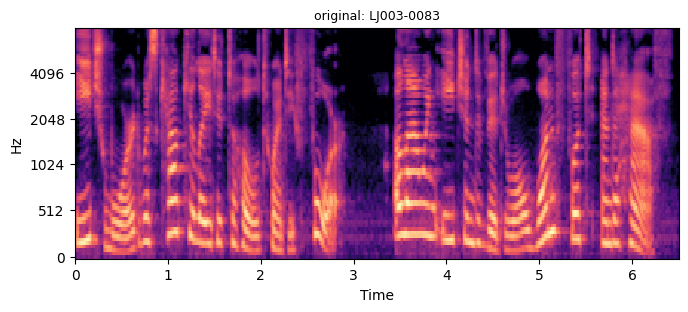

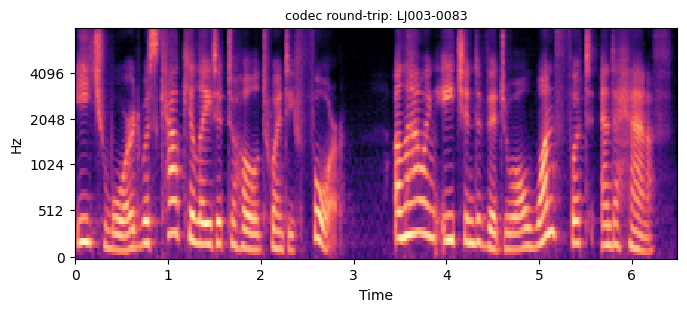

In [9]:
codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz').to(device).eval()
for p in codec.parameters(): p.requires_grad_(False)
CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input
print(f'codebook={CODEBOOK_SIZE}, sr_in/out={CODEC_SR}/{codec.sample_rate_output}')

def load_wav_16k(path):
    arr, sr = sf.read(path, dtype='float32', always_2d=False)
    if arr.ndim > 1: arr = arr.mean(-1)
    wav = torch.from_numpy(arr)
    if sr != CODEC_SR: wav = torchaudio.functional.resample(wav, sr, CODEC_SR)
    return wav  # (T,)

def plot_mel(wav, sr, title=''):
    wav = np.asarray(wav).astype(np.float32)
    if wav.ndim > 1: wav = wav.mean(0)
    S = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=1024, hop_length=256,
                                       n_mels=80, fmin=50, fmax=sr//2)
    fig, ax = plt.subplots(figsize=(max(6, len(wav)/sr*1.2), 3))
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, hop_length=256,
                              x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title, fontsize=9); plt.show()

row = val_df.iloc[0]
wav = load_wav_16k(row['filepath']).to(device)
with torch.no_grad():
    toks = codec.sig_to_toks(wav.unsqueeze(0))
    rec = codec.toks_to_sig(toks).squeeze(0).detach().cpu().numpy()
print(f'{row["id"]}: {wav.shape[-1]/CODEC_SR:.2f}s -> {toks.shape[-1]} tokens')
plot_mel(wav.cpu().numpy(), CODEC_SR, f'original: {row["id"]}')
plot_mel(rec, codec.sample_rate_output, f'codec round-trip: {row["id"]}')

# 3. Precompute features

In [10]:
from tqdm.auto import tqdm
from transformers import GPT2TokenizerFast

In [39]:
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

CACHE_DIR = os.path.join(root_dir, 'tokenized')
os.makedirs(CACHE_DIR, exist_ok=True)
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train.pt')
VAL_CACHE   = os.path.join(CACHE_DIR, 'val.pt')


@torch.no_grad()
def encode_split(df, cache_path, batch_size=16, overwrite=True):
    if os.path.exists(cache_path) and not overwrite:
        print(f'load cache: {cache_path}')
        return torch.load(cache_path, weights_only=False)

    # comment out to precompute on full dataset
    df = df.iloc[:5000]

    recs = df.to_dict('records')
    paths = [r['filepath'] for r in recs]
    order = np.argsort([os.path.getsize(p) for p in paths])
    out = [None] * len(recs)
    for start in tqdm(range(0, len(recs), batch_size)):
        idxs = order[start:start+batch_size]
        wavs = [load_wav_16k(paths[i]) for i in idxs]
        lens = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)
        L = int(lens.max()); batch = torch.zeros(len(wavs), L)
        for j, w in enumerate(wavs): batch[j, :w.numel()] = w
        batch = batch.to(device)
        toks = codec.sig_to_toks(batch, length=(lens/L).to(device))
        tok_lens = ((lens/L).to(device) * toks.shape[-1]).round().clamp(max=toks.shape[-1]).to(torch.long)
        for j, i in enumerate(idxs):
            text_ids = tokenizer.encode(recs[i]['text_norm'], add_special_tokens=False)
            text_ids = torch.tensor(text_ids, dtype=torch.long)
            audio_ids = toks[j, :tok_lens[j]].to(torch.long).cpu()
            out[i] = {
                'id': recs[i]['id'],
                'text': recs[i]['text_norm'],
                'text_ids': text_ids,
                'audio_ids': audio_ids,
                'n_text': int(text_ids.numel()),
                'n_audio': int(audio_ids.numel()),
            }

    torch.save(out, cache_path)
    print(f'saved {len(out)} items to {cache_path}')
    return out


print('tokenize train'); train_items = encode_split(train_df, TRAIN_CACHE)
print('tokenize val');   val_items   = encode_split(val_df,   VAL_CACHE)
a = np.array([r['n_audio'] for r in train_items])
t = np.array([r['n_text']  for r in train_items])
print(f'audio tokens: mean={a.mean():.1f} p95={np.percentile(a,95):.0f} max={a.max()}')
print(f'text  tokens: mean={t.mean():.1f} p95={np.percentile(t,95):.0f} max={t.max()}')

tokenize train


  0%|          | 0/313 [00:00<?, ?it/s]

saved 5000 items to ./data/tokenized/train.pt
tokenize val


  0%|          | 0/82 [00:00<?, ?it/s]

saved 1310 items to ./data/tokenized/val.pt
audio tokens: mean=164.8 p95=244 max=252
text  tokens: mean=20.8 p95=32 max=69


In [40]:
from torch.utils.data import Dataset


class TokenizedLJSpeech(Dataset):
    def __init__(self, cache_path, max_total_len=1024):
        items = torch.load(cache_path, weights_only=False)
        self.items = [it for it in items if it["n_text"] + it["n_audio"] + 2 <= max_total_len]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        it = self.items[i]
        return {
            "id": it["id"],
            "text_ids": it["text_ids"].long(),
            "audio_ids": it["audio_ids"].long(),
        }


def collate(batch):
    B = len(batch)
    text_lens = torch.tensor([b["text_ids"].numel() for b in batch], dtype=torch.long)
    audio_lens = torch.tensor([b["audio_ids"].numel() for b in batch], dtype=torch.long)
    text_ids = torch.zeros(B, int(text_lens.max()), dtype=torch.long)
    audio_ids = torch.zeros(B, int(audio_lens.max()), dtype=torch.long)
    for i, b in enumerate(batch):
        text_ids[i, : b["text_ids"].numel()] = b["text_ids"]
        audio_ids[i, : b["audio_ids"].numel()] = b["audio_ids"]
    return {"text_ids": text_ids, "text_lens": text_lens,
            "audio_ids": audio_ids, "audio_lens": audio_lens}

In [41]:
from torch.utils.data import DataLoader

train_ds = TokenizedLJSpeech(TRAIN_CACHE)
print(train_ds[0])


train_dl = DataLoader(train_ds, collate_fn=collate, batch_size=2)
for k, v in next(iter(train_dl)).items():
    print(k, v.shape)

{'id': 'LJ022-0092', 'text_ids': tensor([  392,   884,  4493,   355,   484, 14762,   481,   307,  1306,  8948,
          284,   262,  1992,   508,   739,   262,  2191,   318,  2672,   284,
          787,  2457, 49157,    13]), 'audio_ids': tensor([7880,  550, 1578, 1642, 5738, 5798, 3304, 7329, 1317, 7123, 7672, 8109,
        2658, 3266, 5956, 5611, 7615, 1910, 5057, 2306, 4609, 7814, 5775, 5134,
        2547, 6843, 1571, 1907, 1892, 1621, 3069, 7165, 4788, 5948, 5310,  131,
        1508, 1464, 5698, 7267, 4324, 2619, 6740, 5445, 7059, 5599, 4102, 4127,
        7836, 7836, 7190, 4630, 6226, 2250, 6535, 4503, 3414, 5976, 1794, 6932,
        1782, 3833, 5733, 1735, 2380, 7709, 2701, 6346,  448, 4700, 4348, 3310,
        6313, 5281, 4962, 7203, 6005, 6946, 7624, 5565, 1777, 6109, 8104, 4263,
        5167, 4445, 5121, 5264, 4711, 4590, 7095, 6768, 6335,  303, 1397, 4595,
        6776, 1008, 1127, 1127, 3019, 1975, 4659, 4850, 4819, 7366,  163, 6685,
        5184, 8095, 5130, 5706, 6830, 45

# 4. TTS class

In [42]:
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel


@dataclass
class GPT2TTSConfig:
    base_model: str = "gpt2"
    codebook_size: int = 8192
    n_special_tokens: int = 2  # BOS, EOS

    @property
    def audio_vocab_size(self) -> int:
        return self.codebook_size + self.n_special_tokens

    @property
    def bos_id(self) -> int:
        return self.codebook_size

    @property
    def eos_id(self) -> int:
        return self.codebook_size + 1


class GPT2TTS(nn.Module):
    def __init__(self, cfg: GPT2TTSConfig):
        super().__init__()
        self.cfg = cfg
        self.base = GPT2LMHeadModel.from_pretrained(cfg.base_model)
        H = self.base.config.n_embd
        V = cfg.audio_vocab_size

        self.audio_emb = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)
        nn.init.normal_(self.audio_emb.weight, std=0.02)
        nn.init.normal_(self.audio_head.weight, std=0.02)

    def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens):
        """Pack a variable-length batch into a single (B, L, H) tensor with mask + labels.

        Inputs
        ------
        text_ids   : LongTensor[B, T_text_max]   padded GPT-2 BPE ids
        text_lens  : LongTensor[B]               actual text length per row
        audio_ids  : LongTensor[B, T_audio_max]  padded FocalCodec ids (all < codebook_size)
        audio_lens : LongTensor[B]               actual audio length per row

        Per-row layout (let tl = text_lens[i], al = audio_lens[i]):

            position :  0 .. tl-1   tl     tl+1 .. tl+al    tl+1+al    tl+2+al .. L-1
            content  :   text       BOS         audio          EOS          PAD

        Returns
        -------
        inputs : FloatTensor[B, L, H]
            Embeddings. Text goes through GPT-2's wte; audio/BOS/EOS through self.audio_emb.
        mask   : LongTensor[B, L]
            1 on real tokens, 0 on PAD. This is the `attention_mask` for GPT-2.
        labels : LongTensor[B, L]
            Target audio ids at positions that SHOULD be predicted (audio + EOS),
            and -100 everywhere else (text, BOS, PAD).
            Do NOT apply the causal shift here — `forward` does that.
        """

        # Gotchas
        # - L must be the padded max across the batch: max_i(tl + al + 2).
        # - Padded positions must be 0 in `mask` AND -100 in `labels` (or pass another "ignore" value to loss function)
        # - The BOS position is NOT a label (we don't train to predict BOS from text).
        # - The EOS position IS a label (we want the model to learn when to stop).
        # - text_emb and audio_emb have the same hidden size H — concatenate on time.

        inputs, mask, labels = None, None, None
        # ↓↓↓ your code here ↓↓↓

        B = text_ids.size(0)
        H = self.base.config.n_embd
        device = text_ids.device

        L = (text_lens + audio_lens + 2).max().item()

        inputs = torch.zeros(B, L, H, device=device)
        mask = torch.zeros(B, L, dtype=torch.long, device=device)
        labels = torch.full((B, L), -100, dtype=torch.long, device=device)

        for i in range(B):

            tl = text_lens[i].item()
            al = audio_lens[i].item()

            text_tok = text_ids[i, :tl]
            text_emb = self.base.transformer.wte(text_tok)

            audio_tok = audio_ids[i, :al]
            audio_emb = self.audio_emb(audio_tok)

            bos_emb = self.audio_emb.weight[self.cfg.bos_id].unsqueeze(0)
            eos_emb = self.audio_emb.weight[self.cfg.eos_id].unsqueeze(0)

            seq_emb = torch.cat([
                text_emb,
                bos_emb,
                audio_emb,
                eos_emb
            ], dim=0)

            seq_len = seq_emb.size(0)

            inputs[i, :seq_len] = seq_emb
            mask[i, :seq_len] = 1

            labels[i, tl + 1 : tl + 1 + al] = audio_tok
            labels[i, tl + 1 + al] = self.cfg.eos_id


          # ↑↑↑ your code here ↑↑↑

        return inputs, mask, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, mask, labels = self._build_inputs(text_ids, text_lens, audio_ids, audio_lens)
        h = self.base.transformer(
            inputs_embeds=inputs, attention_mask=mask, return_dict=True
        ).last_hidden_state
        logits = self.audio_head(h)  # (B, L, V)

        # Compute the causal-LM cross-entropy loss.
        # In a causal LM the hidden state at position t predicts the token at position t+1.
        # Use ignore_index=-100 so masked positions don't contribute. Cast logits to float32
        # before the softmax for numerical stability under bf16/fp16.
        # Expected: a scalar tensor `loss`.


        # ↓↓↓ your code here ↓↓↓
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        loss = F.cross_entropy(
            shift_logits.float().view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100,
        )
                # ↑↑↑ your code here ↑↑↑

        return {"loss": loss, "logits": logits}

    @torch.no_grad()
    def generate_audio(self, text_ids, max_new_tokens=400, temperature=0.9, top_k=50):
        """Autoregressively sample audio tokens conditioned on text.

        Runs [text][BOS] through the transformer once to prime the KV cache,
        leaving `h` as the hidden state after BOS. You write the sampling loop.
        """
        self.eval()
        device = text_ids.device
        text_ids = text_ids.view(-1).long().to(device)
        text_emb = self.base.transformer.wte(text_ids).unsqueeze(0)            # (1, T, H)
        bos = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)            # (1, 1, H)
        prefix = torch.cat([text_emb, bos], dim=1)                             # (1, T+1, H)
        mask = torch.ones(1, prefix.size(1), device=device, dtype=torch.long)

        out = self.base.transformer(
            inputs_embeds=prefix, attention_mask=mask,
            use_cache=True, return_dict=True,
        )
        past = out.past_key_values
        h = out.last_hidden_state[:, -1, :]   # (1, H) — hidden state after BOS

        # Autoregressive sampling loop. Starting from `h` (hidden state after BOS), repeatedly:
        # project to audio-vocab logits, apply temperature + top-k, sample a token, handle
        # stopping, and feed the token back through
        # the transformer using `past`/`mask` to refresh `h`. Stop at EOS or max_new_tokens.
        # Return the collected audio ids as a LongTensor on `device`.

        generated = []
        # ↓↓↓ your code here ↓↓↓

        for _ in range(max_new_tokens):

          logits = self.audio_head(h) / temperature

          if top_k is not None:
              values, _ = torch.topk(logits, top_k)
              min_values = values[:, -1].unsqueeze(-1)
              logits = torch.where(
                  logits < min_values,
                  torch.full_like(logits, -float("inf")),
                  logits,
              )

          probs = F.softmax(logits, dim=-1)

          next_token = torch.multinomial(probs, num_samples=1)

          token_id = next_token.item()

          if token_id == self.cfg.eos_id:
              break

          generated.append(token_id)

          token_emb = self.audio_emb(next_token)

          mask = torch.cat([
              mask,
              torch.ones(1, 1, device=device, dtype=torch.long)
          ], dim=1)

          out = self.base.transformer(
              inputs_embeds=token_emb,
              attention_mask=mask,
              past_key_values=past,
              use_cache=True,
              return_dict=True,
          )

          past = out.past_key_values
          h = out.last_hidden_state[:, -1, :]

        # ↑↑↑ your code here ↑↑↑

        return torch.tensor(generated, dtype=torch.long, device=device)

In [43]:
cfg = GPT2TTSConfig()
tts = GPT2TTS(cfg)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# train call
# tts.forward(**next(iter(train_dl)))

In [44]:
batch = next(iter(train_dl))
out = tts.forward(**batch)

print(out["loss"])
print(out["logits"].shape)

tensor(12.2728, grad_fn=<NllLossBackward0>)
torch.Size([2, 270, 8194])


In [45]:
from tqdm.auto import tqdm

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tts = tts.to(device)

optimizer = torch.optim.AdamW(
    tts.parameters(),
    lr=1e-4,
)

num_epochs = 5

for epoch in range(num_epochs):

    tts.train()

    pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}")

    total_loss = 0

    for batch in pbar:

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        optimizer.zero_grad()

        out = tts(**batch)

        loss = out["loss"]

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    avg_loss = total_loss / len(train_dl)

    print(f"\nEpoch {epoch+1} avg loss: {avg_loss:.4f}")

Epoch 1:   0%|          | 0/2500 [00:00<?, ?it/s]


Epoch 1 avg loss: 8.6972


Epoch 2:   0%|          | 0/2500 [00:00<?, ?it/s]


Epoch 2 avg loss: 8.3785


Epoch 3:   0%|          | 0/2500 [00:00<?, ?it/s]


Epoch 3 avg loss: 8.0002


Epoch 4:   0%|          | 0/2500 [00:00<?, ?it/s]


Epoch 4 avg loss: 7.7058


Epoch 5:   0%|          | 0/2500 [00:00<?, ?it/s]


Epoch 5 avg loss: 7.4479


In [56]:
torch.save(tts.state_dict(), "tts_model.pth")
print("Model saved!")

Model saved!


90 tokens, 3.60s
  text: The quick brown fox jumps over the lazy dog.


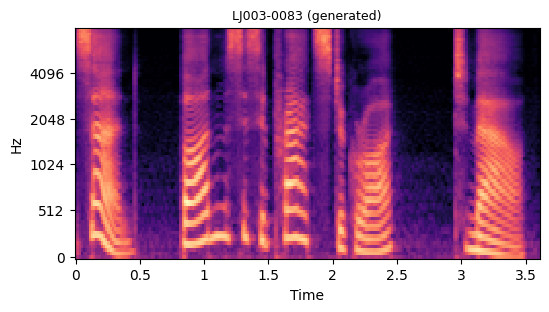

In [52]:
# inference
text = "The quick brown fox jumps over the lazy dog."

def sample_tts(text, max_new=400, temperature=0.9, top_k=100):
    text_ids = torch.tensor(tokenizer.encode(text, add_special_tokens=False), device=device)
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0: return np.zeros(CODEC_SR // 2, dtype=np.float32), toks
    with torch.no_grad():
        wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).detach().cpu().numpy().astype(np.float32)
    return wav, toks

wav, toks = sample_tts(text)
print(f'{toks.numel()} tokens, {wav.shape[-1]/CODEC_SR:.2f}s')
print(f'  text: {text}')
plot_mel(wav, CODEC_SR, f'{row["id"]} (generated)')
display.display(display.Audio(wav, rate=CODEC_SR))

68 tokens
2.72 seconds
text: The quick brown fox jumps over the lazy dog.


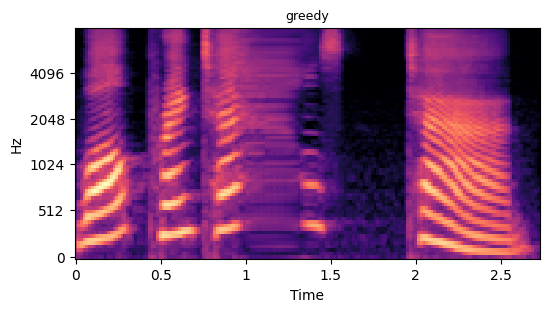

In [65]:
wav, toks = sample_tts(
    text,
    temperature=0.1,
    top_k=1
)
print(f'{toks.numel()} tokens')
print(f'{wav.shape[-1] / CODEC_SR:.2f} seconds')
print(f'text: {text}')

plot_mel(wav, CODEC_SR, 'greedy')

display.display(display.Audio(wav, rate=CODEC_SR))

109 tokens
4.36 seconds


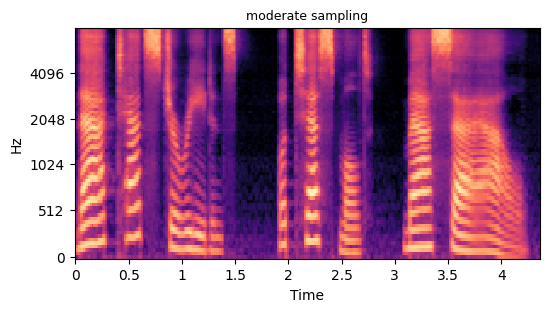

In [60]:
wav, toks = sample_tts(
    text,
    temperature=0.9,
    top_k=50
)

print(f'{toks.numel()} tokens')
print(f'{wav.shape[-1] / CODEC_SR:.2f} seconds')

plot_mel(wav, CODEC_SR, 'moderate sampling')

display.display(display.Audio(wav, rate=CODEC_SR))

95 tokens
3.80 seconds
text: The quick brown fox jumps over the lazy dog.


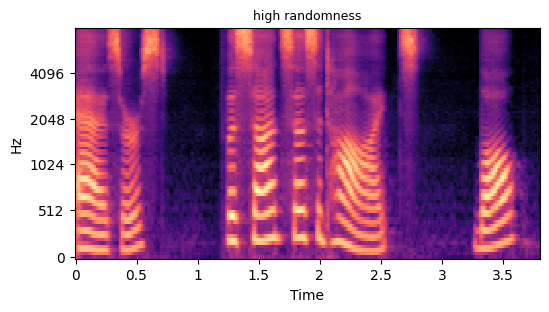

In [62]:
wav, toks = sample_tts(
    text,
    temperature=1.3,
    top_k=200
)
print(f'{toks.numel()} tokens')
print(f'{wav.shape[-1] / CODEC_SR:.2f} seconds')
print(f'text: {text}')

plot_mel(wav, CODEC_SR, 'high randomness')

display.display(display.Audio(wav, rate=CODEC_SR))

TEXT: It’s simple, evocative, and arguably the most peaceful way to demonstrate that you don't need many words to tell a full story.

Strategy: Greedy | temp=0.3 | top_k=20
Generated 248 tokens
Duration: 9.92s


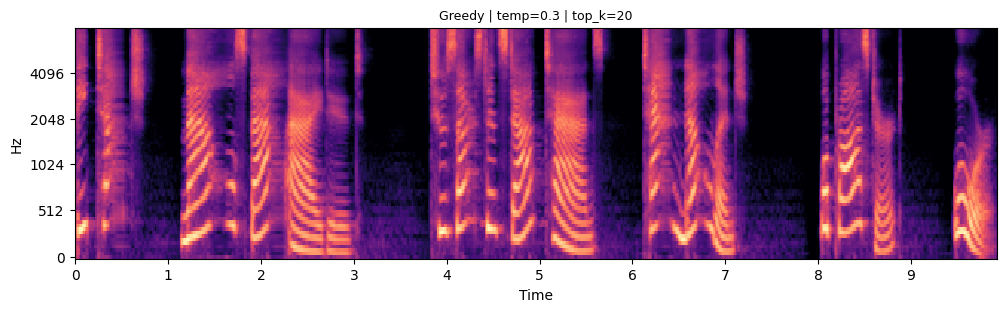


Strategy: Balanced | temp=0.7 | top_k=50
Generated 229 tokens
Duration: 9.16s


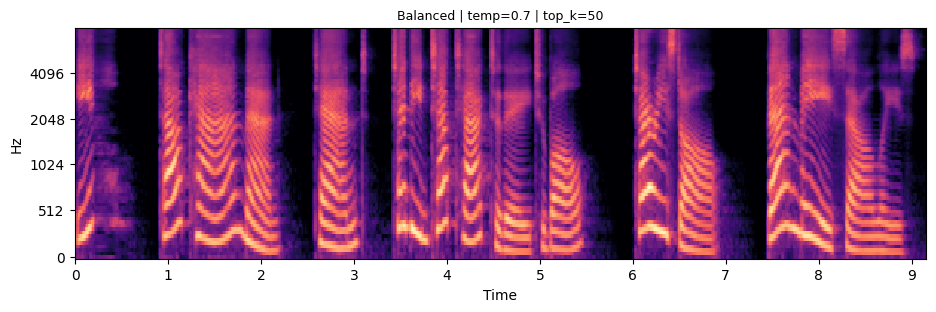


Strategy: high-randomness | temp=1.0 | top_k=100
Generated 211 tokens
Duration: 8.44s


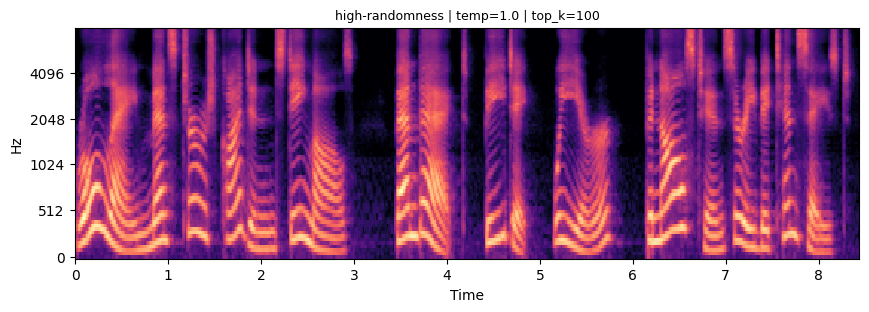

TEXT: The cat slept.

Strategy: Greedy | temp=0.3 | top_k=20
Generated 67 tokens
Duration: 2.68s


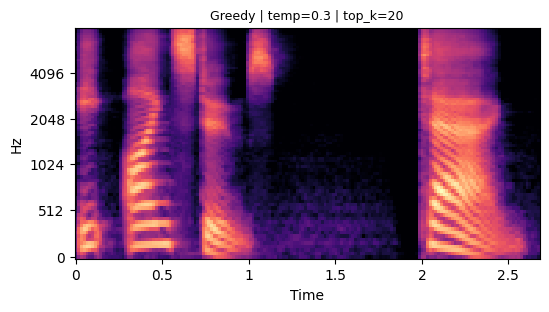


Strategy: Balanced | temp=0.7 | top_k=50
Generated 55 tokens
Duration: 2.20s


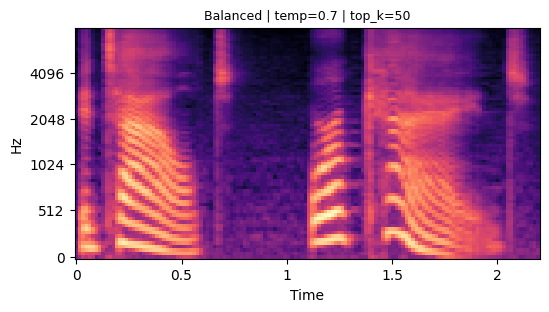


Strategy: high-randomness | temp=1.0 | top_k=100
Generated 19 tokens
Duration: 0.76s


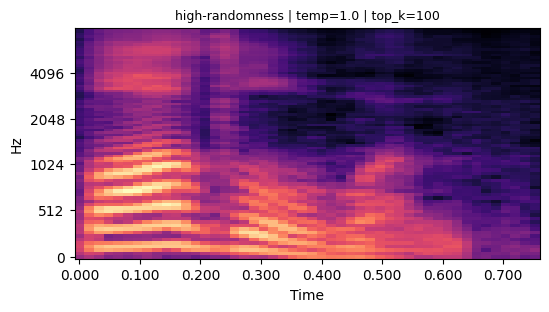

In [69]:
texts = [
    "It’s simple, evocative, and arguably the most peaceful way to demonstrate that you don't need many words to tell a full story.",
    "The cat slept.",
]

strategies = [
    {"name": "Greedy", "temperature": 0.3, "top_k": 20},
    {"name": "Balanced", "temperature": 0.7, "top_k": 50},
    {"name": "high-randomness", "temperature": 1.0, "top_k": 100},
]

results = []

for text in texts:

    print("=" * 80)
    print(f"TEXT: {text}")

    for strat in strategies:

        print(
            f"\nStrategy: {strat['name']} | "
            f"temp={strat['temperature']} | "
            f"top_k={strat['top_k']}"
        )

        wav, toks = sample_tts(
            text=text,
            max_new=400,
            temperature=strat["temperature"],
            top_k=strat["top_k"],
        )

        duration = wav.shape[-1] / CODEC_SR

        print(f"Generated {toks.numel()} tokens")
        print(f"Duration: {duration:.2f}s")

        results.append({
            "text": text,
            "strategy": strat["name"],
            "temperature": strat["temperature"],
            "top_k": strat["top_k"],
            "tokens": toks.numel(),
            "duration": duration,
        })


        plot_mel(
            wav,
            CODEC_SR,
            title=(
                f"{strat['name']} | "
                f"temp={strat['temperature']} | "
                f"top_k={strat['top_k']}"
            )
        )

        display.display(display.Audio(wav, rate=CODEC_SR))


In [70]:
import pandas as pd

df = pd.DataFrame(results)
df

,text,strategy,temperature,top_k,tokens,duration
0,"It’s simple, evocative, and arguably the most ...",Greedy,0.3,20,248,9.92
1,"It’s simple, evocative, and arguably the most ...",Balanced,0.7,50,229,9.16
2,"It’s simple, evocative, and arguably the most ...",high-randomness,1.0,100,211,8.44
3,The cat slept.,Greedy,0.3,20,67,2.68
4,The cat slept.,Balanced,0.7,50,55,2.20
5,The cat slept.,high-randomness,1.0,100,19,0.76


# Homework

Theory:
Answer theory questions in the Google Form.

Practice:

1. Complete the gptTTS code
1. Put together training pipeline with torch or lightning
1. Train gpt2 for TTS task
1. Run inference with different sampling strategies on several texts
1. Compute CER; UTMOS; SECS from xTTS paper (you can use xTTS's library)